<a href="https://colab.research.google.com/github/apopuri584/wriggling_bad2/blob/main/short_time_fourier_transform.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
import os
import pandas as pd
from google.colab import drive
from scipy.signal import stft



In [3]:
drive.mount('/content/drive')


Mounted at /content/drive


In [4]:
import os
import pandas as pd

folder_path = '/content/drive/MyDrive/C. elegans videos/Segmented_Output_Caffeine/10 mM'
file_list = os.listdir(folder_path)

csv_list = []
file_names = []

for filename in file_list:
    if filename.endswith('.csv'):
      print(filename)
      file_names.append(filename)
      full_path = os.path.join(folder_path, filename)
      df = pd.read_csv(full_path)
      csv_list.append(df)
print(f"Loaded {len(csv_list)} CSV files.")
if csv_list:
    print("Head of the first DataFrame:")
    display(csv_list[0].head())

10mM caffeine 10minutes.motion_data.csv
10mM caffeine 15minutes.motion_data.csv
10mM caffeine 30minutes.motion_data.csv
10mM caffeine 1minutes.motion_data.csv
Loaded 4 CSV files.
Head of the first DataFrame:


,frame,worm_id,centroid_x,centroid_y,speed_px_per_frame,heading_deg,body_length_px,curvature_rad_per_step,n_endpoints,contour_skel_px,skel_overlap_px,skel_dice,skel_iou
0,1,12,588.34,997.45,0.690,169.86,22,0.2537,2,22,22,1.0,1.0
1,1,10,473.33,964.40,0.383,-87.36,5,0.0000,2,5,5,1.0,1.0
2,1,9,545.39,943.75,0.697,-133.39,24,0.4093,2,24,24,1.0,1.0
3,1,19,548.56,1127.20,0.383,62.45,3,0.0000,2,3,3,1.0,1.0
4,1,17,331.26,1092.36,1.168,116.37,30,0.3631,2,30,30,1.0,1.0


In [5]:
df = csv_list[0]
sub = df[df['worm_id'] == 12].sort_values('frame')

print(sub.head())


     frame  worm_id  centroid_x  centroid_y  speed_px_per_frame  heading_deg  \
0        1       12      588.34      997.45               0.690       169.86   
30       2       12      587.57      997.55               0.773       172.63   
62       3       12      588.29      997.70               0.734        11.76   
93       4       12      588.76      997.70               0.476         0.18   
129      5       12      589.01      996.74               0.992       -75.83   

     body_length_px  curvature_rad_per_step  n_endpoints  contour_skel_px  \
0                22                  0.2537            2               22   
30               23                  0.3070            2               23   
62               31                  0.9773            3               31   
93               36                  0.8076            3               36   
129              30                  0.3747            2               30   

     skel_overlap_px  skel_dice  skel_iou  
0           

In [6]:
signal  = sub['speed_px_per_frame'].to_numpy()
signal = signal - signal.mean()

print(signal)


[-9.96785714e-01 -9.13785714e-01 -9.52785714e-01 -1.21078571e+00
 -6.94785714e-01 -7.72785714e-01 -4.83785714e-01 -9.50785714e-01
 -6.42785714e-01 -1.18778571e+00 -2.78785714e-01 -1.39778571e+00
 -1.04478571e+00 -3.13785714e-01 -1.21678571e+00  6.88921429e+00
 -1.58378571e+00  6.87721429e+00 -1.54978571e+00 -8.77857143e-02
 -8.06785714e-01 -1.23778571e+00  6.84421429e+00  1.88021429e+00
  1.10142143e+01  1.10214286e-01 -1.23278571e+00 -1.33778571e+00
 -3.48785714e-01 -1.21478571e+00 -1.37578571e+00  4.32142857e-02
 -6.42785714e-01 -1.26578571e+00 -1.25478571e+00 -1.02278571e+00
  1.34202143e+01 -9.51785714e-01 -1.23978571e+00  7.02421429e+00
  3.36521429e+00 -1.68678571e+00 -1.68678571e+00  1.37521429e+00
  2.20321429e+00 -1.12785714e-01 -1.03678571e+00 -9.64785714e-01
 -5.31785714e-01  7.45121429e+00  3.12142857e-02  2.54214286e-01
 -3.57857143e-02 -1.55078571e+00 -1.04878571e+00  5.94621429e+00
 -1.68678571e+00 -6.72785714e-01 -1.68678571e+00 -1.68678571e+00
 -1.68678571e+00 -1.68678

In [7]:
n_frame = df['frame'].max()
print(n_frame)
fs = n_frame/12
print(fs)

337
28.083333333333332


In [8]:
freqs, times, Zxx = stft(signal, fs=fs, nperseg=128)
print(freqs)

[ 0.          0.21940104  0.43880208  0.65820312  0.87760417  1.09700521
  1.31640625  1.53580729  1.75520833  1.97460938  2.19401042  2.41341146
  2.6328125   2.85221354  3.07161458  3.29101562  3.51041667  3.72981771
  3.94921875  4.16861979  4.38802083  4.60742188  4.82682292  5.04622396
  5.265625    5.48502604  5.70442708  5.92382812  6.14322917  6.36263021
  6.58203125  6.80143229  7.02083333  7.24023438  7.45963542  7.67903646
  7.8984375   8.11783854  8.33723958  8.55664062  8.77604167  8.99544271
  9.21484375  9.43424479  9.65364583  9.87304688 10.09244792 10.31184896
 10.53125    10.75065104 10.97005208 11.18945312 11.40885417 11.62825521
 11.84765625 12.06705729 12.28645833 12.50585938 12.72526042 12.94466146
 13.1640625  13.38346354 13.60286458 13.82226562 14.04166667]


In [9]:
import numpy as np
magnitude = np.abs(Zxx)


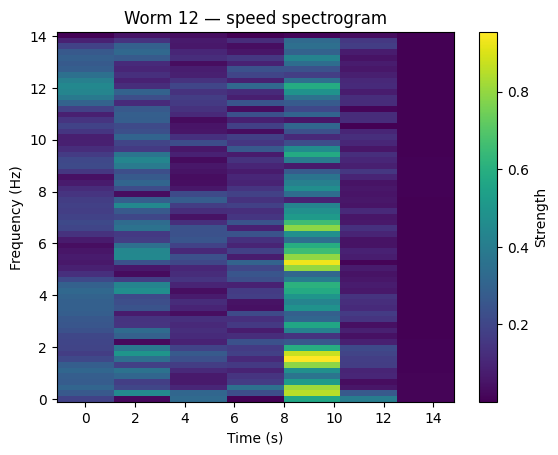

In [10]:
import matplotlib.pyplot as plt

magnitude = np.abs(Zxx)
plt.pcolormesh(times, freqs, magnitude)
plt.xlabel('Time (s)')
plt.ylabel('Frequency (Hz)')
plt.colorbar(label = 'Strength')
plt.title('Worm 12 — speed spectrogram')
plt.show()

In [11]:
dominant_freq_idx = np.argmax(magnitude, axis=0)
print(dominant_freq_idx)

dominant_freqs = freqs[dominant_freq_idx]
print(dominant_freqs)

[55  8  0  2  7  0  0]
[12.06705729  1.75520833  0.          0.43880208  1.53580729  0.
  0.        ]


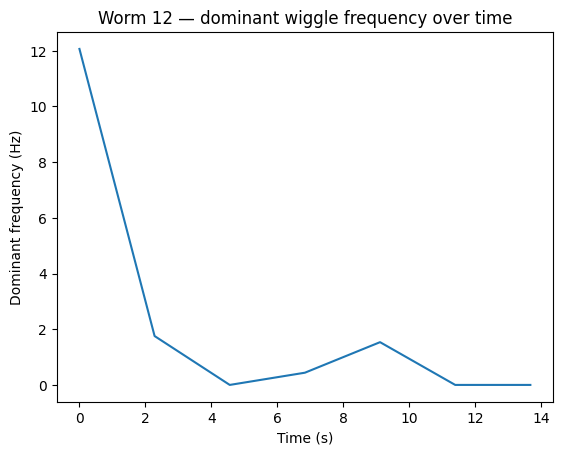

In [12]:
plt.plot(times, dominant_freqs)
plt.xlabel('Time (s)')
plt.ylabel('Dominant frequency (Hz)')
plt.title('Worm 12 — dominant wiggle frequency over time')
plt.show()

In [13]:
def get_average_spectrum(sub, fs, nperseg):
    signal = sub['speed_px_per_frame'].to_numpy()
    signal = signal - signal.mean()
    freqs, times, Zxx = stft(signal, fs=fs, nperseg=nperseg)
    magnitude = np.abs(Zxx)
    avg_spectrum = magnitude.mean(axis=1)
    return freqs, avg_spectrum

In [14]:
freqs, avg_spectrum = get_average_spectrum(sub, fs, 128)
print(avg_spectrum.shape)
print(freqs.shape)

(65,)
(65,)


In [15]:
counts_per_worm = df.groupby('worm_id')['frame'].count()
print(counts_per_worm)

complete_worms = counts_per_worm[counts_per_worm == 337]
print(complete_worms)

worm_id
0      336
1      337
2      337
3      336
4      337
      ... 
201      8
202      8
203      6
204      3
205      2
Name: frame, Length: 206, dtype: int64
worm_id
1     337
2     337
4     337
6     337
7     337
10    337
11    337
17    337
19    337
20    337
21    337
24    337
Name: frame, dtype: int64


In [16]:
all_spectra = []
all_freqs = []



for idx, csv in enumerate(csv_list):
  counts_per_worm = csv.groupby('worm_id')['frame'].count()
  n_frame = csv['frame'].max()
  fs = n_frame/12
  complete_worms = counts_per_worm[counts_per_worm == n_frame]
  spectra_for_this_csv = []
  freqs_for_this_csv = []
  for i in complete_worms.index.tolist():
    sub = csv[csv['worm_id'] ==i].sort_values('frame')
    freqs, avg_spectrum = get_average_spectrum(sub, fs, 128)
    spectra_for_this_csv.append(avg_spectrum)
    freqs_for_this_csv.append(freqs)
    print(f"Worm {i} from {file_names[idx]}: {avg_spectrum.shape}, {freqs.shape}")

  all_spectra.append(spectra_for_this_csv)
  all_freqs.append(freqs_for_this_csv)


freq_data = dict(zip(file_names, all_freqs))
spectra_data = dict(zip(file_names, all_spectra))

Worm 1 from 10mM caffeine 10minutes.motion_data.csv: (65,), (65,)
Worm 2 from 10mM caffeine 10minutes.motion_data.csv: (65,), (65,)
Worm 4 from 10mM caffeine 10minutes.motion_data.csv: (65,), (65,)
Worm 6 from 10mM caffeine 10minutes.motion_data.csv: (65,), (65,)
Worm 7 from 10mM caffeine 10minutes.motion_data.csv: (65,), (65,)
Worm 10 from 10mM caffeine 10minutes.motion_data.csv: (65,), (65,)
Worm 11 from 10mM caffeine 10minutes.motion_data.csv: (65,), (65,)
Worm 17 from 10mM caffeine 10minutes.motion_data.csv: (65,), (65,)
Worm 19 from 10mM caffeine 10minutes.motion_data.csv: (65,), (65,)
Worm 20 from 10mM caffeine 10minutes.motion_data.csv: (65,), (65,)
Worm 21 from 10mM caffeine 10minutes.motion_data.csv: (65,), (65,)
Worm 24 from 10mM caffeine 10minutes.motion_data.csv: (65,), (65,)
Worm 5 from 10mM caffeine 15minutes.motion_data.csv: (65,), (65,)
Worm 7 from 10mM caffeine 15minutes.motion_data.csv: (65,), (65,)
Worm 8 from 10mM caffeine 15minutes.motion_data.csv: (65,), (65,)
Wor

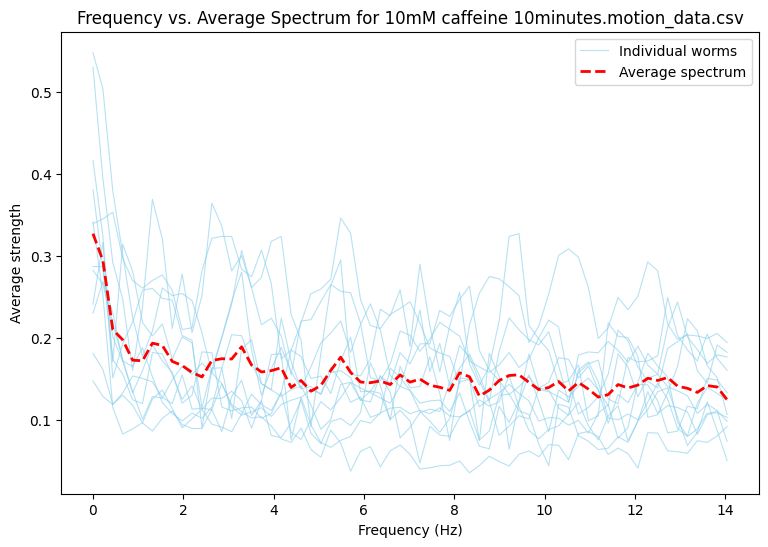

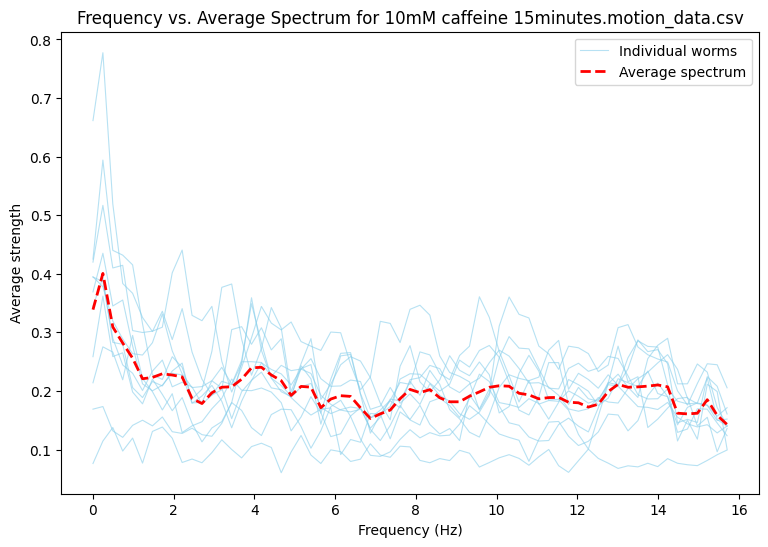

No complete worm data found for 10mM caffeine 30minutes.motion_data.csv. Skipping plot.


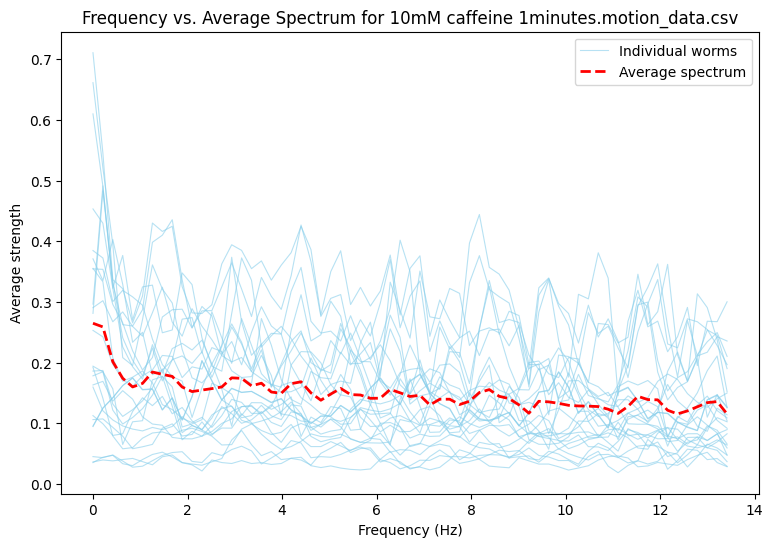

In [17]:
import matplotlib.pyplot as plt
import numpy as np

# Define a fixed color for all individual worm lines within each plot
individual_worm_color = 'skyblue'
# Define a distinct color for the average line
average_line_color = 'red'

for i, filename in enumerate(file_names):
    spectra_list = spectra_data[filename]
    freqs_list = freq_data[filename]

    # Only create a figure and plot if there is data for this CSV
    if spectra_list:
        plt.figure(figsize=(9,6))

        # Plot individual worm spectra
        for idx, spectrum in enumerate(spectra_list):
            # Plot all spectra from the same CSV in the same color
            plt.plot(freqs_list[idx], spectrum, color=individual_worm_color, alpha=0.6, linewidth=0.8, label='Individual worms' if idx == 0 else "")

        # Calculate the average spectrum for this CSV
        # Check if all frequency arrays are identical
        first_freqs = freqs_list[0]
        all_freqs_identical = all(np.array_equal(first_freqs, f) for f in freqs_list)

        if not all_freqs_identical:
            print(f"Warning: Frequencies for worms in {filename} are not identical. Averaging them.")
            average_freqs = np.mean(np.array(freqs_list), axis=0)
        else:
            average_freqs = first_freqs

        # Calculate the element-wise mean of all spectra
        average_spectrum = np.mean(np.array(spectra_list), axis=0)

        # Plot the average spectrum
        plt.plot(average_freqs, average_spectrum, color=average_line_color, linestyle='--', linewidth=2, label='Average spectrum')

        plt.xlabel('Frequency (Hz)')
        plt.ylabel('Average strength')
        plt.legend()
        plt.title(f'Frequency vs. Average Spectrum for {filename}')
        plt.show()
    else:
        print(f"No complete worm data found for {filename}. Skipping plot.")

Worm 1 from 10mM caffeine 10minutes.motion_data.csv: PSD shape (65,), Freqs shape (65,)
Worm 2 from 10mM caffeine 10minutes.motion_data.csv: PSD shape (65,), Freqs shape (65,)
Worm 4 from 10mM caffeine 10minutes.motion_data.csv: PSD shape (65,), Freqs shape (65,)
Worm 6 from 10mM caffeine 10minutes.motion_data.csv: PSD shape (65,), Freqs shape (65,)
Worm 7 from 10mM caffeine 10minutes.motion_data.csv: PSD shape (65,), Freqs shape (65,)
Worm 10 from 10mM caffeine 10minutes.motion_data.csv: PSD shape (65,), Freqs shape (65,)
Worm 11 from 10mM caffeine 10minutes.motion_data.csv: PSD shape (65,), Freqs shape (65,)
Worm 17 from 10mM caffeine 10minutes.motion_data.csv: PSD shape (65,), Freqs shape (65,)
Worm 19 from 10mM caffeine 10minutes.motion_data.csv: PSD shape (65,), Freqs shape (65,)
Worm 20 from 10mM caffeine 10minutes.motion_data.csv: PSD shape (65,), Freqs shape (65,)
Worm 21 from 10mM caffeine 10minutes.motion_data.csv: PSD shape (65,), Freqs shape (65,)
Worm 24 from 10mM caffeine

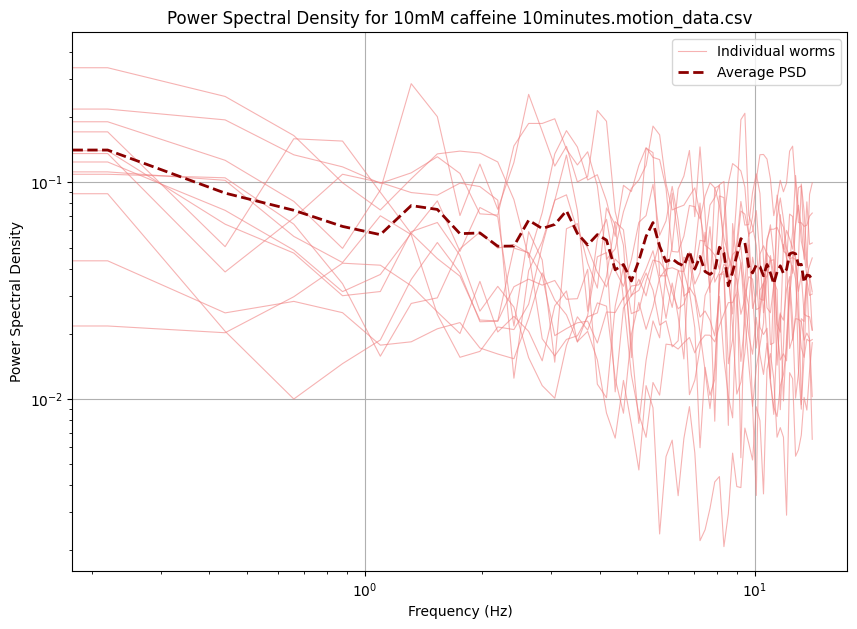

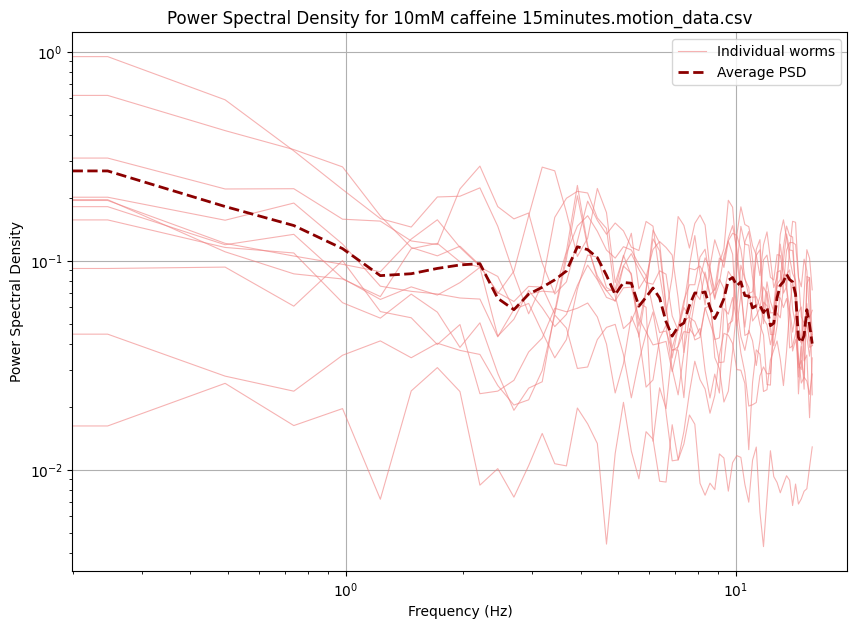

No complete worm data found for 10mM caffeine 30minutes.motion_data.csv for PSD calculation. Skipping plot.


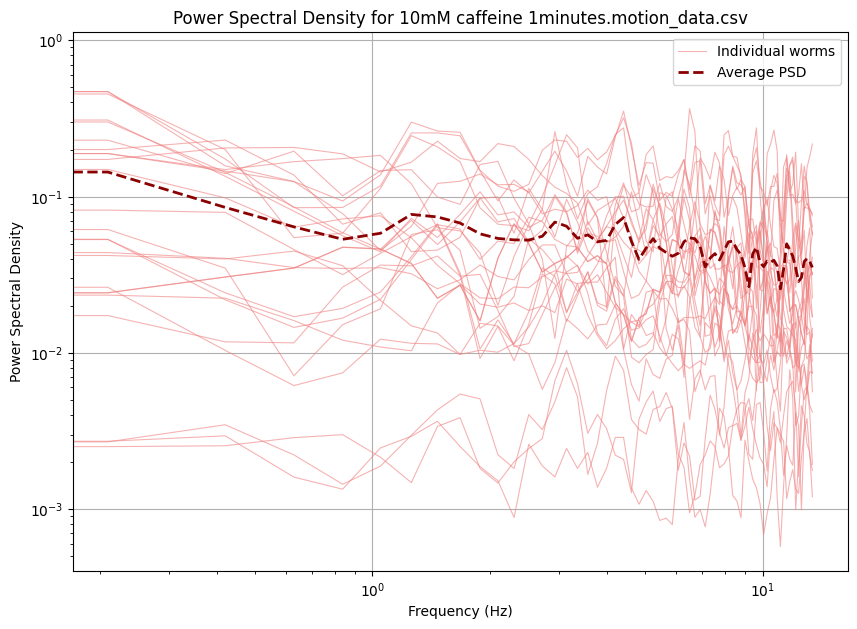

In [18]:
import matplotlib.pyplot as plt
import numpy as np
from scipy.signal import stft

def get_average_psd(sub, fs, nperseg):
    """
    Calculates the average Power Spectral Density (PSD) for a given worm's speed signal.

    Args:
        sub (pd.DataFrame): DataFrame containing motion data for a single worm.
        fs (float): Sampling frequency.
        nperseg (int): Length of each segment for STFT.

    Returns:
        tuple: A tuple containing:
            - freqs (np.ndarray): Frequencies corresponding to the PSD.
            - average_psd (np.ndarray): Average Power Spectral Density.
    """
    signal = sub['speed_px_per_frame'].to_numpy()
    signal = signal - signal.mean() # Mean-center the signal

    freqs, times, Zxx = stft(signal, fs=fs, nperseg=nperseg)
    # Calculate Power Spectral Density (PSD) as magnitude squared of STFT
    psd = np.abs(Zxx)**2
    average_psd = psd.mean(axis=1) # Average PSD over time segments
    return freqs, average_psd

# Initialize dictionaries to store PSD data
all_psd_spectra = []
all_psd_freqs = []

# Loop through each CSV file
for idx, csv_df in enumerate(csv_list):
    counts_per_worm = csv_df.groupby('worm_id')['frame'].count()
    n_frame = csv_df['frame'].max()
    fs = n_frame / 12 # Calculate sampling frequency for the current CSV
    complete_worms = counts_per_worm[counts_per_worm == n_frame]

    psd_spectra_for_this_csv = []
    psd_freqs_for_this_csv = []

    for worm_id in complete_worms.index.tolist():
        sub_df = csv_df[csv_df['worm_id'] == worm_id].sort_values('frame')
        freqs, avg_psd = get_average_psd(sub_df, fs, nperseg=128)
        psd_spectra_for_this_csv.append(avg_psd)
        psd_freqs_for_this_csv.append(freqs)
        print(f"Worm {worm_id} from {file_names[idx]}: PSD shape {avg_psd.shape}, Freqs shape {freqs.shape}")

    all_psd_spectra.append(psd_spectra_for_this_csv)
    all_psd_freqs.append(psd_freqs_for_this_csv)

# Create dictionaries for easy access by filename
freq_psd_data = dict(zip(file_names, all_psd_freqs))
spectra_psd_data = dict(zip(file_names, all_psd_spectra))

# Plotting the power spectral density graphs

# Define a fixed color for all individual worm lines within each plot
individual_worm_color_psd = 'lightcoral'
# Define a distinct color for the average line
average_line_color_psd = 'darkred'

for i, filename in enumerate(file_names):
    psd_spectra_list = spectra_psd_data[filename]
    psd_freqs_list = freq_psd_data[filename]

    if psd_spectra_list:
        plt.figure(figsize=(10, 7))

        # Plot individual worm PSDs
        for idx, psd_spectrum in enumerate(psd_spectra_list):
            plt.plot(psd_freqs_list[idx], psd_spectrum, color=individual_worm_color_psd, alpha=0.6, linewidth=0.8, label='Individual worms' if idx == 0 else "")

        # Calculate the average PSD for this CSV
        # Check if all frequency arrays are identical (they should be for STFT with same fs and nperseg)
        first_psd_freqs = psd_freqs_list[0]
        all_psd_freqs_identical = all(np.array_equal(first_psd_freqs, f) for f in psd_freqs_list)

        if not all_psd_freqs_identical:
            print(f"Warning: Frequencies for worms in {filename} are not identical for PSD. Averaging them.")
            average_psd_freqs = np.mean(np.array(psd_freqs_list), axis=0)
        else:
            average_psd_freqs = first_psd_freqs

        # Calculate the element-wise mean of all PSD spectra
        average_psd_spectrum = np.mean(np.array(psd_spectra_list), axis=0)

        # Plot the average PSD spectrum
        plt.plot(average_psd_freqs, average_psd_spectrum, color=average_line_color_psd, linestyle='--', linewidth=2, label='Average PSD')

        plt.xlabel('Frequency (Hz)')
        plt.ylabel('Power Spectral Density')
        plt.legend()
        plt.title(f'Power Spectral Density for {filename}')
        plt.grid(True)
        plt.xscale('log') # Often PSDs are plotted on a log scale for frequency
        plt.yscale('log') # Often PSDs are plotted on a log scale for power
        plt.show()
    else:
        print(f"No complete worm data found for {filename} for PSD calculation. Skipping plot.")